In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

revert_df = pd.concat(map(pd.read_csv, glob(join('../../../', f"*topk*.csv"))))

#INPUT INPUT_SIZE*4 + INPUT_SIZE*4 + DIFF_SIZE*4 
#OUTPUT OUTPUTSIZE * 4 note: outputsize = inputsize

revert_df['mem_bytes'] = (revert_df['size'] * (4))  + revert_df['outputsize'] * 4
revert_df['bandwidth_gbps'] = (revert_df['mem_bytes']) / (revert_df['time_us']*1000) #GB/s

In [5]:
revert_df.head()

,operator,dtype,size,density,outputsize,time_us,mem_bytes,bandwidth_gbps
0,topk_cann_1024,fp16,81920,None,1024,36.75,331776,9.027918
1,topk_cann_1024,fp16,2703360,None,1024,1246.96,10817536,8.675127
2,topk_cann_1024,fp16,5324800,None,1024,272.62,21303296,78.142822
3,topk_cann_1024,fp16,7946240,None,1024,387.69,31789056,81.996069
4,topk_cann_1024,fp16,10567680,None,1024,506.00,42274816,83.547067


<Axes: xlabel='size', ylabel='bandwidth_gbps'>

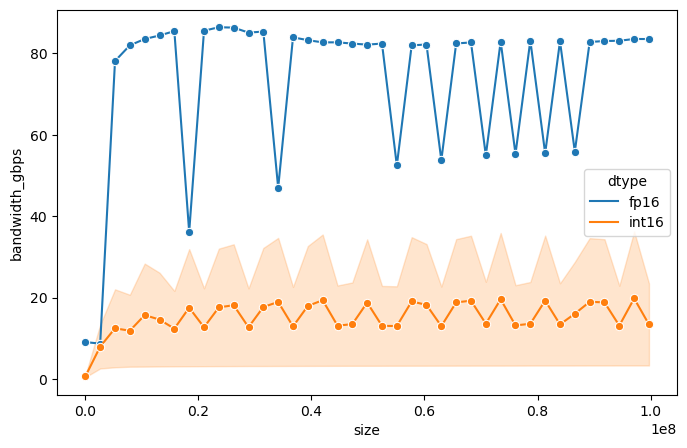

In [6]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_gbps', hue='dtype', data=revert_df, marker='o')
